# STATISTICS

In [1]:
# import libraries
import os
import glob
import pandas as pd
import numpy as np
import math
import scipy
import matplotlib.pyplot as plt
import math
import xml.etree.ElementTree as ET
import seaborn as sns
import seaborn.objects as so
from sklearn.preprocessing import StandardScaler
import umap

curfolder = os.getcwd()
print(curfolder)

flesh_folder = os.path.dirname(curfolder)
features = flesh_folder + '/Feature_Extraction_folder/feature_extraction_with2d_nijmegen.csv'

features = pd.read_csv(features)

features



/opt/anaconda3/envs/umap_env2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/StatisticsFolder


,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_elbow_boundingboxmv,left_elbow_boundingboxmv,right_shoulder_boundingboxmv,left_shoulder_boundingboxmv,right_wrist_intermittency,left_wrist_intermittency,right_elbow_intermittency,left_elbow_intermittency,right_shoulder_imtermittency,left_shoulder_intermittency
0,23.0,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.021997,0.045602,0.008101,0.001815,0.090165,0.152371,0.021997,0.045602,0.008101,0.001815
2,16.0,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,0.010798,0.005989,0.001531,0.000508,0.051233,0.043372,0.010798,0.005989,0.001531,0.000508
3,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.031391,0.031519,0.001467,0.001288,0.109630,0.119282,0.031391,0.031519,0.001467,0.001288
4,30.0,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,0.003179,0.042114,0.003894,0.011132,0.004167,0.186586,0.003179,0.042114,0.003894,0.011132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.025753,0.016156,0.013745,0.013845,0.039921,0.032609,0.025753,0.016156,0.013745,0.013845
434,39.0,39.0,Berlin,Woman / Weiblich,Deutsch,1.0,"English fluent, Spanisch basic",3.0,41.0,Left-handed / Linkshänder*in,...,0.017116,0.011810,0.001412,0.000284,0.124296,0.111899,0.017116,0.011810,0.001412,0.000284
435,52.0,21.0,Berlin,Man / Männlich,Deutsch,1.0,"Englisch- sehr gut, Italienisch - grundlegend",3.0,53.0,Right-handed / Rechtshänder*in,...,0.050667,0.078414,0.014418,0.011240,0.153856,0.207660,0.050667,0.078414,0.014418,0.011240
436,59.0,27.0,"Deutschland, Gera",Woman / Weiblich,Deutsch,1.0,"Englisch (gute Kenntnisse), französisch (Grund...",3.0,40.0,Right-handed / Rechtshänder*in,...,0.007455,0.003774,0.000831,0.000330,0.070408,0.062623,0.007455,0.003774,0.000831,0.000330


# Normalize all the feature data for dimensionality reduction

In [2]:

normed_features = features.copy()
# remove the entropy measures that calculate each arm separately
normed_features = normed_features.drop(['total_body_entropy2D', 'total_body_variability2D'], axis=1)
normed_features2 = normed_features.copy()
normed_features
# normalizes all the features


normed_features2[normed_features2.columns[17:]] = StandardScaler().fit_transform(normed_features[normed_features.columns[17:]])
cols_to_embed = normed_features2.columns[17:]
normed_features2 = normed_features2[cols_to_embed].dropna()

normed_features

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_elbow_boundingboxmv,left_elbow_boundingboxmv,right_shoulder_boundingboxmv,left_shoulder_boundingboxmv,right_wrist_intermittency,left_wrist_intermittency,right_elbow_intermittency,left_elbow_intermittency,right_shoulder_imtermittency,left_shoulder_intermittency
0,23.0,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.021997,0.045602,0.008101,0.001815,0.090165,0.152371,0.021997,0.045602,0.008101,0.001815
2,16.0,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,0.010798,0.005989,0.001531,0.000508,0.051233,0.043372,0.010798,0.005989,0.001531,0.000508
3,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.031391,0.031519,0.001467,0.001288,0.109630,0.119282,0.031391,0.031519,0.001467,0.001288
4,30.0,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,0.003179,0.042114,0.003894,0.011132,0.004167,0.186586,0.003179,0.042114,0.003894,0.011132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.025753,0.016156,0.013745,0.013845,0.039921,0.032609,0.025753,0.016156,0.013745,0.013845
434,39.0,39.0,Berlin,Woman / Weiblich,Deutsch,1.0,"English fluent, Spanisch basic",3.0,41.0,Left-handed / Linkshänder*in,...,0.017116,0.011810,0.001412,0.000284,0.124296,0.111899,0.017116,0.011810,0.001412,0.000284
435,52.0,21.0,Berlin,Man / Männlich,Deutsch,1.0,"Englisch- sehr gut, Italienisch - grundlegend",3.0,53.0,Right-handed / Rechtshänder*in,...,0.050667,0.078414,0.014418,0.011240,0.153856,0.207660,0.050667,0.078414,0.014418,0.011240
436,59.0,27.0,"Deutschland, Gera",Woman / Weiblich,Deutsch,1.0,"Englisch (gute Kenntnisse), französisch (Grund...",3.0,40.0,Right-handed / Rechtshänder*in,...,0.007455,0.003774,0.000831,0.000330,0.070408,0.062623,0.007455,0.003774,0.000831,0.000330


# Dimensionality Reduction with UMAP

In [3]:
# call dimensionality reduction package
reducer = umap.UMAP()

# create embeddings
embedding = reducer.fit_transform(normed_features2[normed_features2.columns[17:]])
embedding.shape
embeddings = pd.DataFrame(embedding)

# add embeddings to the dataframe
features["X_embeddings"] = embeddings.iloc[:, 0]
features["Y_embeddings"] = embeddings.iloc[:, 1]
normed_features["X_embeddings"] = embeddings.iloc[:, 0]
normed_features["Y_embeddings"] = embeddings.iloc[:, 1]

Plot all gesture embeddings:

<Axes: xlabel='X_embeddings', ylabel='Y_embeddings'>

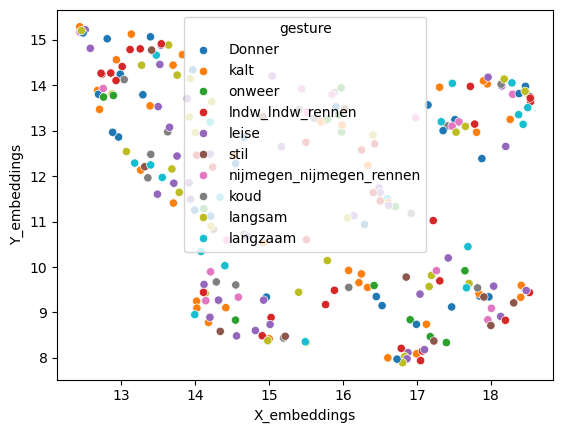

In [4]:
sns.scatterplot(data=normed_features, x="X_embeddings", y="Y_embeddings", hue="gesture")

# Set generation zero for chain 2 and chain 3


In [5]:
# set generation zero for leise chain 2
fix_row = normed_features[normed_features['fileID'] == "leise_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "leise_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'leise_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for leise chain 3
fix_row = normed_features[normed_features['fileID'] == "leise_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "leise_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'leise_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for langsam chain 2
fix_row = normed_features[normed_features['fileID'] == "langsam_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "langsam_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'langsam_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for langsam chain 3
fix_row = normed_features[normed_features['fileID'] == "langsam_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "langsam_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'langsam_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for rennen chain 2
fix_row = normed_features[normed_features['fileID'] == "rennen_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "rennen_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'rennen_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for rennen chain 3
fix_row = normed_features[normed_features['fileID'] == "rennen_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "rennen_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'rennen_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for Donner chain 2
fix_row = normed_features[normed_features['fileID'] == "Donner_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "Donner_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'Donner_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for Donner chain 3
fix_row = normed_features[normed_features['fileID'] == "Donner_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "Donner_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'Donner_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for kalt chain 2
fix_row = normed_features[normed_features['fileID'] == "kalt_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "kalt_g_ch2_g0_compr.mp4"
fix_row["chainID"] = "ch2g0"
fix_row["chain_number"] = 2
fix_row["gesture_chain"] = 'kalt_g_ch2'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

# set generation zero for kalt chain 3
fix_row = normed_features[normed_features['fileID'] == "kalt_g_ch1_g0_compr.mp4"].copy()
fix_row["fileID"] = "kalt_g_ch3_g0_compr.mp4"
fix_row["chainID"] = "ch3g0"
fix_row["chain_number"] = 3
fix_row["gesture_chain"] = 'kalt_g_ch3'
normed_features = pd.concat([normed_features, fix_row], ignore_index=True)

normed_features

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_shoulder_boundingboxmv,left_shoulder_boundingboxmv,right_wrist_intermittency,left_wrist_intermittency,right_elbow_intermittency,left_elbow_intermittency,right_shoulder_imtermittency,left_shoulder_intermittency,X_embeddings,Y_embeddings
0,23.0,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.847122,9.362572
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.008101,0.001815,0.090165,0.152371,0.021997,0.045602,0.008101,0.001815,17.128490,8.740726
2,16.0,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,0.001531,0.000508,0.051233,0.043372,0.010798,0.005989,0.001531,0.000508,14.661015,12.851744
3,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001467,0.001288,0.109630,0.119282,0.031391,0.031519,0.001467,0.001288,17.398405,8.337826
4,30.0,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,0.003894,0.011132,0.004167,0.186586,0.003179,0.042114,0.003894,0.011132,16.334934,12.231236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001722,0.003246,0.000699,0.010065,0.001152,0.003291,0.001722,0.003246,NaN,NaN
442,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000486,0.002043,0.058529,0.078590,0.003942,0.010804,0.000486,0.002043,NaN,NaN
443,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000486,0.002043,0.058529,0.078590,0.003942,0.010804,0.000486,0.002043,NaN,NaN
444,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.008101,0.001815,0.090165,0.152371,0.021997,0.045602,0.008101,0.001815,17.128490,8.740726


# Save Normed Features Dataframe with Embeddings


In [6]:
globals()["normed_features"] = normed_features
globals()["normed_features"].to_csv(os.path.join(curfolder, f'{"normed_features"}.csv'), index=False)

# Euclidean Distances between Gestures

Compare one vector to others

In [7]:
# returns the euclidean distance between two normalized gesutre vectors
def calculate_distances(feature_vector1, feature_vector2):
    squared_diff =np.square(feature_vector1-feature_vector2)
    sum_squared_diff = np.sum(squared_diff)
    eucl_distance = math.sqrt(sum_squared_diff)
    return eucl_distance

# returns the distance between one gesture to every other gesture
def calculate_distances_to_all(target_segment_index, array):
    target_segment = array[target_segment_index]
    distances = np.empty(array.shape[0])
    i = 0
    for row in array:
        distances[i] = calculate_distances(target_segment, row)
        i = i+1
    return distances


Comparing all vectors to each other and saving in a dataframe

In [8]:
# This code was modified from code written by Šárka Kadavá

## why do we start at 32 for this?
interseg_dist = np.empty(normed_features[normed_features.columns[32:60]].shape)
interseg_dist = pd.DataFrame(interseg_dist)
interseg_dist = pd.DataFrame()

#make individual id for each segment
df_of_vectors = normed_features[normed_features.columns[32:60]].copy()
df_of_vectors = df_of_vectors.to_numpy()

# calculate distance between each segment
for i in range (normed_features[normed_features.columns[32:60]].shape[0]):
    id = normed_features.loc[i, 'fileID']
    interseg_dist_vector = calculate_distances_to_all(i, df_of_vectors)
    interseg_dist = interseg_dist.rename(index={i: id})
    interseg_dist = interseg_dist.rename(columns={i: id})
    interseg_dist[id] = interseg_dist_vector
    index = interseg_dist.index

# save to dataframe
interseg_dist.to_csv('interseg_dist_extended.csv', index=True)
interseg_dist = pd.read_csv(os.path.join(curfolder, 'interseg_dist_extended.csv')).set_index('Unnamed: 0')

interseg_dist

,Donner_g_ch2_g3_compr.mp4,kalt_g_ch1_g0_compr.mp4,Donner_g_ch1_g16_compr.mp4,onweer_g_ch2_g2_compr.mp4,kalt_g_ch2_g10_compr.mp4,lndw_lndw_rennen_g_ch1_g12_compr.mp4,leise_g_ch2_g17_compr.mp4,kalt_g_ch2_g6_compr.mp4,Donner_g_ch1_g5_compr.mp4,onweer_g_ch1_g4_compr.mp4,...,langsam_g_ch3_g19_compr.mp4,Unnamed: 438,leise_g_ch2_g0_compr.mp4,leise_g_ch3_g0_compr.mp4,langsam_g_ch2_g0_compr.mp4,langsam_g_ch3_g0_compr.mp4,Donner_g_ch2_g0_compr.mp4,Donner_g_ch3_g0_compr.mp4,kalt_g_ch2_g0_compr.mp4,kalt_g_ch3_g0_compr.mp4
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kalt_g_ch1_g0_compr.mp4,NaN,0.000000,638.288881,63.549488,2406.663899,230.808259,3400.348732,513.477194,1505.104143,686.282083,...,1517.078751,NaN,1256.043415,1256.043415,511.466540,511.466540,250.477934,250.477934,0.000000,0.000000
Donner_g_ch1_g16_compr.mp4,NaN,638.288881,0.000000,695.787962,1831.957409,641.324852,2874.835147,274.200764,897.203739,758.452269,...,915.049985,NaN,796.612872,796.612872,130.520888,130.520888,428.436809,428.436809,638.288881,638.288881
onweer_g_ch2_g2_compr.mp4,NaN,63.549488,695.787962,0.000000,2456.125732,221.887128,3441.253656,557.147403,1555.496057,683.333475,...,1570.816951,NaN,1296.363767,1296.363767,569.239081,569.239081,296.292847,296.292847,63.549488,63.549488
kalt_g_ch2_g10_compr.mp4,NaN,2406.663899,1831.957409,2456.125732,0.000000,2371.349569,2524.639287,1918.594674,1010.386961,2255.499026,...,925.128778,NaN,1838.626428,1838.626428,1932.484805,1932.484805,2162.182102,2162.182102,2406.663899,2406.663899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
langsam_g_ch3_g0_compr.mp4,NaN,511.466540,130.520888,569.239081,1932.484805,529.180375,2991.432296,210.621874,1012.064404,709.888660,...,1022.602692,NaN,890.212537,890.212537,0.000000,0.000000,302.662429,302.662429,511.466540,511.466540
Donner_g_ch2_g0_compr.mp4,NaN,250.477934,428.436809,296.292847,2162.182102,264.934723,3223.197494,265.799558,1262.448783,590.789831,...,1278.255415,NaN,1089.872760,1089.872760,302.662429,302.662429,0.000000,0.000000,250.477934,250.477934
Donner_g_ch3_g0_compr.mp4,NaN,250.477934,428.436809,296.292847,2162.182102,264.934723,3223.197494,265.799558,1262.448783,590.789831,...,1278.255415,NaN,1089.872760,1089.872760,302.662429,302.662429,0.000000,0.000000,250.477934,250.477934


In [12]:
normed_features.columns[17:60]

normed_features

Index(['ARM_TOTAL_speed2D_mean', 'ARM_TOTAL_speed2D_sd',
       'ARM_TOTAL_speed2D_range', 'LEG_TOTAL_speed2D_mean',
       'LEG_TOTAL_speed2D_sd', 'LEG_TOTAL_speed2D_range', 'left_index_space2D',
       'left_wrist_space2D', 'left_elbow_space2D', 'total_left_arm_space2D',
       'right_index_space2D', 'right_wrist_space2D', 'right_elbow_space2D',
       'total_right_arm_space2D', 'left_ankle_space2D', 'left_knee_space2D',
       'left_hip_space2D', 'total_left_leg_space2D', 'right_ankle_space2D',
       'right_knee_space2D', 'right_hip_space2D', 'total_right_leg_space2D',
       'nose_space2D', 'total_head_space2D', 'total_gesture_space2D',
       'right_wrist_entropy2D', 'left_wrist_entropy2D', 'right_knee_entropy2D',
       'left_knee_entropy2D', 'right_ankle_entropy2D', 'left_ankle_entropy2D',
       'total_body_entropy2Daggregated', 'right_wrist_variability2D',
       'left_wrist_variability2D', 'total_body_variability2Daggregated',
       'right_wrist_boundingboxmv', 'left_wrist_

# Create dataframe which compares participant gestures to previous participant gestures

In [15]:
big_df = pd.DataFrame(index=range(61), columns=['participantID', 'generation_number', 'chain_number', 'chainID', 'age', 'extrovert', 'TotalLanguages', 'Gender', 'NumOfNativeLanguages', 'diff_in_age', 'diff_in_extrovert', 'diff_in_gender', 'diff_in_TotalNativeLanguages', 'diff_in_TotalLanguages',
                               'diff_in_gesture_space_Donner', 'diff_in_entropy_Donner', 'diff_in_variability_Donner',
                               'diff_in_gesture_space_kalt', 'diff_in_entropy_kalt', 'diff_in_variability_kalt',
                                 'diff_in_gesture_space_langsam', 'diff_in_entropy_langsam','diff_in_variability_langsam',
                                   'diff_in_gesture_space_leise', 'diff_in_entropy_leise', 'diff_in_variability_leise',
                                     'diff_in_gesture_space_rennen','diff_in_entropy_rennen', 'diff_in_variability_rennen',
                                       'diff_in_gesture_space_mean', 'diff_in_entropy_mean', 'diff_in_variability_mean', 
                                       'total_dist_Donner', 'total_dist_kalt' , 'total_dist_langsam', 'total_dist_leise', 'total_dist_rennen', 'total_dist_mean'])
big_df['participantID'] = big_df.index

# rename row zero which got messed up in the interseg_dist matrix
interseg_dist = interseg_dist.rename(index={str(0): 'rennen_g_ch3_g12_compr.mp4'})
for i in range(interseg_dist.shape[0]-1):

    # get the current gesture
    curr_gesture = interseg_dist.index[i]

    # get the row of features of the current gesture and aspects of the gesture
    curr_features_row = normed_features[normed_features['fileID'] == curr_gesture]

normed_features

In [28]:
interseg_dist

,Donner_g_ch2_g3_compr.mp4,kalt_g_ch1_g0_compr.mp4,Donner_g_ch1_g16_compr.mp4,onweer_g_ch2_g2_compr.mp4,kalt_g_ch2_g10_compr.mp4,lndw_lndw_rennen_g_ch1_g12_compr.mp4,leise_g_ch2_g17_compr.mp4,kalt_g_ch2_g6_compr.mp4,Donner_g_ch1_g5_compr.mp4,onweer_g_ch1_g4_compr.mp4,...,langsam_g_ch3_g19_compr.mp4,Unnamed: 438,leise_g_ch2_g0_compr.mp4,leise_g_ch3_g0_compr.mp4,langsam_g_ch2_g0_compr.mp4,langsam_g_ch3_g0_compr.mp4,Donner_g_ch2_g0_compr.mp4,Donner_g_ch3_g0_compr.mp4,kalt_g_ch2_g0_compr.mp4,kalt_g_ch3_g0_compr.mp4
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kalt_g_ch1_g0_compr.mp4,NaN,0.000000,638.288881,63.549488,2406.663899,230.808259,3400.348732,513.477194,1505.104143,686.282083,...,1517.078751,NaN,1256.043415,1256.043415,511.466540,511.466540,250.477934,250.477934,0.000000,0.000000
Donner_g_ch1_g16_compr.mp4,NaN,638.288881,0.000000,695.787962,1831.957409,641.324852,2874.835147,274.200764,897.203739,758.452269,...,915.049985,NaN,796.612872,796.612872,130.520888,130.520888,428.436809,428.436809,638.288881,638.288881
onweer_g_ch2_g2_compr.mp4,NaN,63.549488,695.787962,0.000000,2456.125732,221.887128,3441.253656,557.147403,1555.496057,683.333475,...,1570.816951,NaN,1296.363767,1296.363767,569.239081,569.239081,296.292847,296.292847,63.549488,63.549488
kalt_g_ch2_g10_compr.mp4,NaN,2406.663899,1831.957409,2456.125732,0.000000,2371.349569,2524.639287,1918.594674,1010.386961,2255.499026,...,925.128778,NaN,1838.626428,1838.626428,1932.484805,1932.484805,2162.182102,2162.182102,2406.663899,2406.663899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
langsam_g_ch3_g0_compr.mp4,NaN,511.466540,130.520888,569.239081,1932.484805,529.180375,2991.432296,210.621874,1012.064404,709.888660,...,1022.602692,NaN,890.212537,890.212537,0.000000,0.000000,302.662429,302.662429,511.466540,511.466540
Donner_g_ch2_g0_compr.mp4,NaN,250.477934,428.436809,296.292847,2162.182102,264.934723,3223.197494,265.799558,1262.448783,590.789831,...,1278.255415,NaN,1089.872760,1089.872760,302.662429,302.662429,0.000000,0.000000,250.477934,250.477934
Donner_g_ch3_g0_compr.mp4,NaN,250.477934,428.436809,296.292847,2162.182102,264.934723,3223.197494,265.799558,1262.448783,590.789831,...,1278.255415,NaN,1089.872760,1089.872760,302.662429,302.662429,0.000000,0.000000,250.477934,250.477934


In [43]:
# creates a dataframe with all comparison columns
interseg_dist = pd.read_csv(os.path.join(curfolder, 'interseg_dist_extended.csv')).set_index('Unnamed: 0')
nijmegen_gestures  = ['koud', 'langzaam', 'nijmegen_nijmegen_rennen', 'onweer', 'stil']
## ADD IN EVENT COLUMN?
big_df = pd.DataFrame(index=range(10000), columns=['participantID', 'generation_number', 'chain_number', 'chainID', 'age', 'extrovert', 'TotalLanguages', 'Gender', 'NumOfNativeLanguages', 'diff_in_age', 'diff_in_extrovert', 'diff_in_gender', 'diff_in_TotalNativeLanguages', 'diff_in_TotalLanguages',
                               'diff_in_gesture_space_Donner', 'diff_in_entropy_Donner', 'diff_in_variability_Donner',
                               'diff_in_gesture_space_kalt', 'diff_in_entropy_kalt', 'diff_in_variability_kalt',
                                 'diff_in_gesture_space_langsam', 'diff_in_entropy_langsam','diff_in_variability_langsam',
                                   'diff_in_gesture_space_leise', 'diff_in_entropy_leise', 'diff_in_variability_leise',
                                     'diff_in_gesture_space_rennen','diff_in_entropy_rennen', 'diff_in_variability_rennen',
                                       'diff_in_gesture_space_mean', 'diff_in_entropy_mean', 'diff_in_variability_mean', 
                                       'total_dist_Donner', 'total_dist_kalt' , 'total_dist_langsam', 'total_dist_leise', 'total_dist_rennen', 'total_dist_mean'])
big_df['participantID'] = big_df.index

# rename row zero which got messed up in the interseg_dist matrix
interseg_dist = interseg_dist.rename(index={str(0): 'rennen_g_ch3_g12_compr.mp4'})
#normed_features = normed_features.drop(437)
interseg_dist = interseg_dist.loc[interseg_dist.index.notna()]


for i in range(1, interseg_dist.shape[0]-2):
    print(i)

    # get the current gesture
    curr_gesture = interseg_dist.index[i]

    # get the row of features of the current gesture and aspects of the gesture
    curr_features_row = normed_features[normed_features['fileID'] == curr_gesture]
    gesture = curr_features_row["gesture"].iloc[0]
    generation_number = curr_features_row["generation_number"].iloc[0]
    generation_number = generation_number.astype(int)

    # if the current gesture is seed zero, go to the next iteration
    if generation_number == 0:
        continue
    chain_number = curr_features_row["chain_number"].iloc[0]
    chain_number =chain_number.astype(int)
    chainID = curr_features_row["chainID"].iloc[0]
    participantID_curr = curr_features_row["participantID"].iloc[0]
    #get the event
    event = curr_features_row["event"].iloc[0]
    ## if 
    # get the previous gesture
    previous_gesture = gesture + "_g_ch" + str(chain_number) + "_g" + str((generation_number)-1) + "_compr.mp4"

    # if either of the gestures are the ones we don't have video for, skip this iteration
    if curr_gesture == "rennen_g_ch1_g17_compr.mp4" or curr_gesture == "langsam_g_ch2_g8_compr.mp4" or curr_gesture == "langsam_g_ch2_g19_compr.mp4" or previous_gesture== "rennen_g_ch1_g17_compr.mp4" or previous_gesture == "langsam_g_ch2_g8_compr.mp4" or previous_gesture== "langsam_g_ch2_g19_compr.mp4" or previous_gesture == 'koud_g_ch2_g0_compr.mp4' or previous_gesture == "onweer_g_ch2_g0_compr.mp4" or previous_gesture == 'Donner_g_ch2_g3_compr.mp4' or previous_gesture == 'nijmegen_nijmegen_rennen_g_ch1_g0_compr.mp4' or previous_gesture == 'stil_g_ch1_g0_compr.mp4' or previous_gesture == "langzaam_g_ch1_g0_compr.mp4" or previous_gesture == "kalt_g_ch2_g7_compr.mp4" or previous_gesture == "langzaam_g_ch2_g0_compr.mp4" or previous_gesture == "stil_g_ch2_g0_compr.mp4" or previous_gesture == "nijmegen_nijmegen_rennen_g_ch2_g0_compr.mp4" or previous_gesture == "lndw_lndw_rennen_g_ch2_g0_compr.mp4" or previous_gesture == "onweer_g_ch1_g0_compr.mp4" or previous_gesture == "koud_g_ch1_g0_compr.mp4" or previous_gesture == "lndw_lndw_rennen_g_ch3_g0_compr.mp4":
        continue
    
    # get the previous gesture in the correct event (nijmegen or lndw)
    prev_features_row = normed_features[
    (normed_features['fileID'] == previous_gesture) &
    (normed_features['event'] == event)
]

    ##GILLIAN, THIS IS WHERE YOU STOPPED EDITING. MAYBE YOU DO NEED TO adjust this so that the event is indicated in the participant_id_curr somehow.
    ## adding information about the current gesture:
    if event == 'nijmegen':
        participantID_curr = (participantID_curr)*1000
    big_df.loc[participantID_curr, 'generation_number'] = generation_number
    big_df.loc[participantID_curr, 'chain_number'] = chain_number
    big_df.loc[participantID_curr, 'chainID'] = chainID


    #### COMPARING DISTANCES ######
    # get the overall distances between the two gestures and add it to the correct cell 
    distance = interseg_dist.loc[previous_gesture, curr_gesture]
    big_df.loc[participantID_curr, 'total_dist_' + gesture] =distance
    # get the difference between gesture spaces and the current gesture space
    gesture_space_diff = abs(curr_features_row["total_gesture_space2D"].iloc[0] - prev_features_row["total_gesture_space2D"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_gesture_space_' + gesture] =gesture_space_diff
    big_df.loc[participantID_curr, 'gesture_space_' + gesture] = curr_features_row["total_gesture_space2D"].iloc[0]
     # get the difference between entrophies and the current entropy
    entropy_diff = abs(curr_features_row["total_body_entropy2Daggregated"].iloc[0] - prev_features_row["total_body_entropy2Daggregated"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_entropy_' + gesture] = entropy_diff
    big_df.loc[participantID_curr, 'entropy_' + gesture] = curr_features_row["total_body_entropy2Daggregated"].iloc[0]
    # # get the difference between variabilities and the current variabilities
    variability_diff = abs(curr_features_row["total_body_variability2Daggregated"].iloc[0] - prev_features_row["total_body_variability2Daggregated"].iloc[0])
    big_df.loc[participantID_curr, 'diff_in_variability_' + gesture] = variability_diff
    big_df.loc[participantID_curr, 'variability_' + gesture] = curr_features_row["total_body_variability2Daggregated"].iloc[0]     


    # if age hasn't been filled in yet:
    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'age'].iloc[0]):
    participant_ages = big_df.loc[big_df['participantID'] == participantID_curr, 'age']

    if not participant_ages.empty and pd.isna(participant_ages.iloc[0]):
        #get the distance between the ages
        previous_age = prev_features_row["Age"].iloc[0]
        curr_age = curr_features_row["Age"].iloc[0]
        big_df.loc[participantID_curr, 'age'] = curr_age
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_age) or math.isnan(curr_age):
            continue
    #get the difference in ages
        diff_in_age = int(abs(curr_age - previous_age))
        big_df.loc[participantID_curr, 'diff_in_age'] = diff_in_age

    participant_ext = big_df.loc[big_df['participantID'] == participantID_curr, 'extrovert']

    if not participant_ext.empty and pd.isna(participant_ext.iloc[0]):
    #get the difference in extroversion
    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'extrovert'].iloc[0]):
        previous_extrovert = prev_features_row["Extroversion"].iloc[0]
        curr_extrovert = curr_features_row["Extroversion"].iloc[0]
        big_df.loc[participantID_curr, 'extrovert'] = curr_extrovert
        # if we don't know the extroversion, skip this iteration
        if math.isnan(previous_extrovert) or math.isnan(curr_extrovert):
            continue
        #get the difference in extroversion
        diff_in_extrovert = int(abs(curr_extrovert - previous_extrovert))
        big_df.loc[participantID_curr, 'diff_in_extrovert'] = diff_in_extrovert

    participant_lang = big_df.loc[big_df['participantID'] == participantID_curr, 'TotalLanguages']

    if not participant_lang.empty and pd.isna(participant_lang.iloc[0]):
    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'TotalLanguages'].iloc[0]):
        #get the distance between the ages
        previous_langs = prev_features_row["TotalLanguages"].iloc[0]
        curr_langs = curr_features_row["TotalLanguages"].iloc[0]
        big_df.loc[participantID_curr, 'TotalLanguages'] = curr_langs
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_langs) or math.isnan(curr_langs):
            continue
    #get the difference in ages
        diff_in_TotalLanguages = int(abs(curr_langs - previous_langs))
        big_df.loc[participantID_curr, 'diff_in_TotalLanguages'] = diff_in_TotalLanguages

    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'NumOfNativeLanguages'].iloc[0]):
    participant_numlang = big_df.loc[big_df['participantID'] == participantID_curr, 'NumOfNativeLanguages']

    if not participant_numlang.empty and pd.isna(participant_numlang.iloc[0]):
        #get the distance between the ages
        previous_Nlangs = prev_features_row["NumOfNativeLanguages"].iloc[0]
        curr_Nlangs = curr_features_row["NumOfNativeLanguages"].iloc[0]
        big_df.loc[participantID_curr, 'NumOfNativeLanguages'] = curr_Nlangs
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_Nlangs) or math.isnan(curr_Nlangs):
            continue
    #get the difference in native languages
        diff_in_TotalNativeLanguages = int(abs(curr_Nlangs - previous_Nlangs))
        big_df.loc[participantID_curr, 'diff_in_TotalNativeLanguages'] = diff_in_TotalNativeLanguages

    #if pd.isna(big_df.loc[big_df['participantID'] == participantID_curr, 'Gender'].iloc[0]):
    participant_gender = big_df.loc[big_df['participantID'] == participantID_curr, 'Gender']

    if not participant_gender.empty and pd.isna(participant_gender.iloc[0]):
        #get the distance between the ages
        previous_gender = prev_features_row["Gender"].iloc[0]
        curr_gender = curr_features_row["Gender"].iloc[0]
        big_df.loc[participantID_curr, 'Gender'] = curr_gender
        # if we don't know the ages, skip this iteration
        if math.isnan(previous_Nlangs) or math.isnan(curr_Nlangs):
            continue
    #get the difference in gender (0 means no difference, 1 means difference)

        diff_in_Gender = int(previous_gender != curr_gender)
        big_df.loc[participantID_curr, 'diff_in_gender'] = diff_in_Gender



# FINDING THE MEAN DIFFERENCES
big_df['diff_in_gesture_space_mean'] = big_df[['diff_in_gesture_space_Donner', 'diff_in_gesture_space_kalt', 'diff_in_gesture_space_langsam', 'diff_in_gesture_space_leise', 'diff_in_gesture_space_rennen']].mean(axis=1)
big_df['diff_in_entropy_mean'] = big_df[['diff_in_entropy_Donner', 'diff_in_entropy_kalt', 'diff_in_entropy_langsam', 'diff_in_entropy_leise', 'diff_in_entropy_rennen']].mean(axis=1)
big_df['diff_in_variability_mean'] = big_df[['diff_in_variability_Donner', 'diff_in_variability_kalt', 'diff_in_variability_langsam', 'diff_in_variability_leise', 'diff_in_variability_rennen']].mean(axis=1)
big_df['total_dist_mean'] = big_df[['total_dist_Donner', 'total_dist_kalt', 'total_dist_langsam', 'total_dist_leise', 'total_dist_rennen']].mean(axis=1)

# FINDING THE MEAN FEATURES
big_df['gesture_space_mean'] = big_df[['gesture_space_Donner', 'gesture_space_kalt', 'gesture_space_langsam', 'gesture_space_leise', 'gesture_space_rennen']].mean(axis=1)
big_df['entropy_mean'] = big_df[['entropy_Donner', 'entropy_kalt', 'entropy_langsam', 'entropy_leise', 'entropy_rennen']].mean(axis=1)
big_df['variability_mean'] = big_df[['variability_Donner', 'variability_kalt', 'variability_langsam', 'variability_leise', 'variability_rennen']].mean(axis=1)

# Saving to Csv File
globals()["big_df"] = big_df
globals()["big_df"].to_csv(os.path.join(curfolder, f'{"gesture_to_prev_gesture"}.csv'), index=False)

interseg_dist
curr_gesture
big_df

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


KeyError: "['gesture_space_rennen'] not in index"

In [36]:
participantID
#indices_to_drop = interseg_dist[interseg_dist[''].isna()].index

,Donner_g_ch2_g3_compr.mp4,kalt_g_ch1_g0_compr.mp4,Donner_g_ch1_g16_compr.mp4,onweer_g_ch2_g2_compr.mp4,kalt_g_ch2_g10_compr.mp4,lndw_lndw_rennen_g_ch1_g12_compr.mp4,leise_g_ch2_g17_compr.mp4,kalt_g_ch2_g6_compr.mp4,Donner_g_ch1_g5_compr.mp4,onweer_g_ch1_g4_compr.mp4,...,langsam_g_ch3_g19_compr.mp4,Unnamed: 438,leise_g_ch2_g0_compr.mp4,leise_g_ch3_g0_compr.mp4,langsam_g_ch2_g0_compr.mp4,langsam_g_ch3_g0_compr.mp4,Donner_g_ch2_g0_compr.mp4,Donner_g_ch3_g0_compr.mp4,kalt_g_ch2_g0_compr.mp4,kalt_g_ch3_g0_compr.mp4
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [188]:
# create a final dataframe with everything that needed to perform statistics including feature data and comparison data
final_dataframe = normed_features[['participantID', 'Age', 'Gender', 'NumOfNativeLanguages', 'TotalLanguages', 'Extroversion', 'fileID', 'chainID', 'generation_number', 'chain_number', 'gesture', 'gesture_chain', 'total_gesture_space2D', 'total_body_entropy2Daggregated', 'total_body_variability2Daggregated', 'X_embeddings', 'Y_embeddings']].copy()

for index, row in final_dataframe.iterrows():
    # get the relevent information for the current gesture
    participantID = row['participantID']
    gesture = row['gesture']
    final_dataframe.loc[index, "generation_number"] = (final_dataframe.loc[index, "generation_number"]) + 1
    curr_row = big_df[big_df["participantID"] == participantID]
    # find the total distance between this gesture and the previous gesture
    final_dataframe.loc[index, 'total_distance'] = curr_row['total_dist_' + gesture].iloc[0]
    # find the diff_in_gesture_space between this gesture and the previous gesture
    final_dataframe.loc[index, 'diff_in_gesture_space'] = curr_row['diff_in_gesture_space_' + gesture].iloc[0]
    # find the diff_in_entropy between this gesture and the previous gesture 
    final_dataframe.loc[index, 'diff_in_entropy'] = curr_row['diff_in_entropy_' + gesture].iloc[0]
    # find the diff_in_variability between this gesture and the previous gesture 
    final_dataframe.loc[index, 'diff_in_variability'] = curr_row['diff_in_variability_' + gesture].iloc[0]
    # find the difference in age an extroversion between this participant and the previous
    final_dataframe.loc[index, 'diff_in_age'] = curr_row['diff_in_age'].iloc[0]
    final_dataframe.loc[index, 'diff_in_extrovet'] = curr_row['diff_in_extrovert'].iloc[0]
    final_dataframe.loc[index, 'diff_in_gender'] = curr_row['diff_in_gender'].iloc[0]
    final_dataframe.loc[index, 'diff_in_TotalLanguages'] = curr_row['diff_in_TotalLanguages'].iloc[0]
    final_dataframe.loc[index, 'diff_in_TotalNativeLanguages'] = curr_row['diff_in_TotalNativeLanguages'].iloc[0]

    # get the categorical age
    Age = curr_row["age"].iloc[0]
    age_category = ""
    if Age < 12:
        age_category = "Gen_Alpha"
    if Age >= 12 and Age <28:
        age_category = "Gen_Z"
    if Age >= 28 and Age <45:
        age_category = "Millenial"
    if Age >= 45 and Age <60:
        age_category = "GenX"
    if Age >= 60 and Age <78:
        age_category = "Baby_Boomer"
    if Age >=78:
        age_category = "Silent_Gen"

    final_dataframe.loc[index, 'Age_category'] = age_category

    #get the categorical extroversion
    extrovert = curr_row["extroversion"].iloc[0]
    extrovert_category = ""
    if extrovert < 50:
        extrovert_category = "Introvert"
    if Age >= 50:
        extrovert_category = "Extrovert"

    final_dataframe.loc[index, 'Extrovert_category'] = extrovert_category

# save to a dataframe
globals()["final_dataframe"] = final_dataframe
globals()["final_dataframe"].to_csv(os.path.join(curfolder, f'{"final_stats_dataframe"}.csv'), index=False)